# Results & Ablation Study

This notebook auto-discovers the structured experiment outputs in the repository root and `all_outputs/`, and aggregates:

- main LR sweeps
- extra hierarchy / two-step / span pipelines
- Reddit / mental-health backbone sweeps
- ablation-matrix runs
- model soup results
- standard ensemble search results
- cross-version ensemble searches from `outputs_cross_version_ensembles`


In [18]:
from pathlib import Path

from src.results_analysis import (
    ADVANCED_ORDER,
    CORE_ABLATION_ORDER,
    EXTRA_PIPELINE_ORDER,
    build_contribution_explanation_rows,
    build_contribution_rows,
    build_experiment_gain_rows,
    build_findings_summary,
    build_soup_gain_rows,
    configure_plot_style,
    discover_artifact_dirs,
    display_markdown,
    display_rows,
    format_delta,
    format_metric,
    load_ensemble_search_rows,
    load_model_soup_rows,
    merge_run_rows,
    pick_rows,
    plot_barh,
    plot_learning_curves,
    sort_rows_by_metric,
    best_by_family,
    summarize_artifact_coverage,
    top_row,
)

configure_plot_style()


In [19]:
PROJECT_ROOT = Path('.')
ARTIFACT_SEARCH_ROOTS = [PROJECT_ROOT, PROJECT_ROOT / 'all_outputs']

ARTIFACT_DIRS = []
seen = set()
for search_root in ARTIFACT_SEARCH_ROOTS:
    if not search_root.exists():
        continue
    for path in discover_artifact_dirs(search_root):
        resolved = path.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        ARTIFACT_DIRS.append(path)

assert ARTIFACT_DIRS, 'No structured artifact directories were found.'
print('Searching artifact roots:')
for root in ARTIFACT_SEARCH_ROOTS:
    if root.exists():
        print(f'  - {root.resolve()}')

print('\nUsing artifact directories:')
for path in ARTIFACT_DIRS:
    print(f'  - {path.resolve()}')


Searching artifact roots:
  - /home/ismail/Documents/NLP_assignment
  - /mnt/hdd/ismail/nlp

Using artifact directories:
  - /home/ismail/Documents/NLP_assignment/outputs
  - /home/ismail/Documents/NLP_assignment/outputs_cross_version_ensembles
  - /home/ismail/Documents/NLP_assignment/outputs_hier
  - /home/ismail/Documents/NLP_assignment/outputs_new_final_v2
  - /home/ismail/Documents/NLP_assignment/outputs_new_final_v5
  - /mnt/hdd/ismail/nlp/outputs
  - /mnt/hdd/ismail/nlp/outputs_new_final
  - /mnt/hdd/ismail/nlp/outputs_new_final_clean
  - /mnt/hdd/ismail/nlp/outputs_new_final_v2
  - /mnt/hdd/ismail/nlp/outputs_new_final_v3


In [20]:
run_rows, logs_by_run_key, log_rows, sweep_rows, topk_rows, result_rows = merge_run_rows(ARTIFACT_DIRS)
soup_rows, best_soup_rows = load_model_soup_rows(ARTIFACT_DIRS)
soup_gain_rows = build_soup_gain_rows(soup_rows, run_rows)
ensemble_rows, ensemble_best_by_size_rows, ensemble_top_two_rows = load_ensemble_search_rows(ARTIFACT_DIRS)

best_rows = best_by_family(run_rows)
best_rows_strict = best_by_family(run_rows, metric_key='best_strict_f1')

best_default_rows = best_by_family(run_rows, backbone='default')
best_default_rows_strict = best_by_family(run_rows, metric_key='best_strict_f1', backbone='default')

coverage_rows = summarize_artifact_coverage(run_rows, soup_rows, ensemble_rows)
contribution_rows = build_contribution_rows(run_rows, soup_rows, ensemble_rows, best_rows=best_rows)
contribution_explanation_rows = build_contribution_explanation_rows(run_rows, soup_rows, ensemble_rows, best_rows=best_rows)
core_gain_rows = build_experiment_gain_rows(best_default_rows, CORE_ABLATION_ORDER)
advanced_gain_rows = build_experiment_gain_rows(best_default_rows, ADVANCED_ORDER)
extra_gain_rows = build_experiment_gain_rows(best_default_rows, EXTRA_PIPELINE_ORDER)
findings = build_findings_summary(run_rows, soup_rows, ensemble_rows, best_rows=best_rows)

best_single_relaxed = top_row(run_rows, 'best_relaxed_f1')
best_single_strict = top_row(run_rows, 'best_strict_f1')
best_soup_relaxed = top_row(soup_rows, 'best_relaxed_f1')
best_soup_strict = top_row(soup_rows, 'best_strict_f1')
best_ensemble_relaxed = top_row(ensemble_rows, 'best_overall_by_relaxed_f1') or top_row(ensemble_rows, 'best_overall_relaxed_f1')
best_ensemble_strict = top_row(ensemble_rows, 'best_overall_by_strict_f1') or top_row(ensemble_rows, 'best_overall_strict_f1')

display_rows(
    coverage_rows,
    columns=['artifact_root', 'num_runs', 'num_families', 'num_backbones', 'num_soups', 'num_ensemble_searches', 'best_relaxed_f1', 'best_strict_f1'],
)
print(f'Total merged run rows: {len(run_rows)}')
print(f'Total soup result rows: {len(soup_rows)}')
print(f'Total ensemble search rows: {len(ensemble_rows)}')


,artifact_root,num_runs,num_families,num_backbones,num_soups,num_ensemble_searches,best_relaxed_f1,best_strict_f1
0,outputs,1,1,1,0,0,0.317,0.172414
1,outputs_cross_version_ensembles,0,0,0,0,1,-inf,-inf
2,outputs_hier,1,1,1,2,0,0.552,0.380165
3,outputs_new_final,1,1,1,0,0,0.317,0.172414
4,outputs_new_final_clean,46,16,1,40,3,0.579,0.440816
5,outputs_new_final_v2,46,16,1,36,3,0.604,0.475771
6,outputs_new_final_v3,12,4,1,0,0,0.577,0.380000
7,outputs_new_final_v5,195,65,3,100,0,0.613,0.510638


Total merged run rows: 302
Total soup result rows: 178
Total ensemble search rows: 7


## Coverage & Executive Summary

This section dynamically summarizes the currently discovered experiment artifacts, the strongest single runs, soups, and ensembles, and the main takeaways. No scores are hard coded; everything is recomputed from the loaded result files each time the notebook runs.


In [21]:
snapshot_lines = [
    f'- Discovered **{len(ARTIFACT_DIRS)}** structured artifact roots.',
    f'- Loaded **{len(run_rows)}** merged run rows, **{len(soup_rows)}** soup rows, and **{len(ensemble_rows)}** ensemble-search rows.',
]

if best_single_relaxed:
    snapshot_lines.append(
        f"- Best single-run relaxed result: **{best_single_relaxed['experiment_name']}** from `{best_single_relaxed['artifact_root']}` at **{format_metric(best_single_relaxed['best_relaxed_f1'])}** relaxed F1."
    )
if best_single_strict:
    snapshot_lines.append(
        f"- Best single-run strict result: **{best_single_strict['experiment_name']}** from `{best_single_strict['artifact_root']}` at **{format_metric(best_single_strict['best_strict_f1'])}** strict F1."
    )
if best_soup_relaxed:
    snapshot_lines.append(
        f"- Best soup by relaxed F1: **{best_soup_relaxed['experiment_name']}** at **{format_metric(best_soup_relaxed['best_relaxed_f1'])}**."
    )
if best_ensemble_relaxed:
    snapshot_lines.append(
        f"- Best ensemble by relaxed F1: **{best_ensemble_relaxed['experiment_name']}** at **{format_metric(best_ensemble_relaxed.get('best_overall_by_relaxed_f1', best_ensemble_relaxed.get('best_overall_relaxed_f1')))}**."
    )
if best_ensemble_strict:
    snapshot_lines.append(
        f"- Best ensemble by strict F1: **{best_ensemble_strict['experiment_name']}** at **{format_metric(best_ensemble_strict.get('best_overall_by_strict_f1', best_ensemble_strict.get('best_overall_strict_f1')))}**."
    )

display_markdown('### Snapshot\n' + '\n'.join(snapshot_lines))
display_markdown('### Key Findings\n' + '\n'.join(f'- {finding}' for finding in findings))


### Snapshot
- Discovered **10** structured artifact roots.
- Loaded **302** merged run rows, **178** soup rows, and **7** ensemble-search rows.
- Best single-run relaxed result: **deberta_definition_lr5em05** from `outputs_new_final_v5` at **0.613** relaxed F1.
- Best single-run strict result: **gliner_finetune_lr2em05** from `outputs_new_final_v5` at **0.511** strict F1.
- Best soup by relaxed F1: **recall_boost_ow02_s42_lr2em05_soup** at **0.595**.
- Best ensemble by relaxed F1: **ensemble_search_v2_v5_top7_relaxed_strict** at **0.635**.
- Best ensemble by strict F1: **ensemble_search_v2_v5_top7_relaxed_strict** at **0.518**.

### Key Findings
- Best single-run relaxed result: DeBERTa + Definition Prompting (`deberta_definition_lr5em05`; Best Relaxed F1 0.613) from `outputs_new_final_v5`.
- Best single-run strict result: Gliner Finetune (`gliner_finetune_lr2em05`; Best Strict F1 0.511) from `outputs_new_final_v5`.
- Within the core default-backbone ablations, the strongest variant improves relaxed F1 over the baseline by +0.018.
- The best extra pipeline changes relaxed F1 by +0.009 relative to the default DeBERTa baseline.
- The strongest non-default backbone run changes relaxed F1 by -0.062 relative to the default DeBERTa baseline.
- The best model soup reaches relaxed F1 0.595, which is +0.000 relative to the default DeBERTa baseline.
- The best ensemble improves on the best single run by +0.022 in relaxed F1.
- Under strict F1, the best ensemble changes performance by +0.007 compared with the best single run.

## Contribution Gains

These tables show how each family of changes is currently paying off relative to the best default-backbone DeBERTa baseline. The deltas are computed at notebook runtime, so they keep tracking the latest results as the experiments improve.


In [22]:
print('Core ablations vs the default DeBERTa baseline:')
display_rows(
    core_gain_rows,
    columns=['display_name', 'experiment_name', 'best_relaxed_f1', 'best_strict_f1', 'delta_relaxed_vs_reference', 'delta_strict_vs_reference', 'artifact_root'],
)

print('\nAdvanced recipes vs the default DeBERTa baseline:')
display_rows(
    advanced_gain_rows,
    columns=['display_name', 'experiment_name', 'best_relaxed_f1', 'best_strict_f1', 'delta_relaxed_vs_reference', 'delta_strict_vs_reference', 'artifact_root'],
)

print('\nExtra pipelines vs the default DeBERTa baseline:')
display_rows(
    extra_gain_rows,
    columns=['display_name', 'experiment_name', 'best_relaxed_f1', 'best_strict_f1', 'delta_relaxed_vs_reference', 'delta_strict_vs_reference', 'artifact_root'],
)


Core ablations vs the default DeBERTa baseline:


,display_name,experiment_name,best_relaxed_f1,best_strict_f1,delta_relaxed_vs_reference,delta_strict_vs_reference,artifact_root
0,BiLSTM-CRF,bilstm_crf_lr0p0005,0.296,0.255924,-0.299,-0.152835,outputs_new_final_v5
1,DeBERTa Baseline,deberta_baseline_lr2em05,0.595,0.408759,0.000,0.000000,outputs_new_final_v2
2,+ Focal Loss,deberta_focal_lr2em05,0.541,0.340836,-0.054,-0.067923,outputs_new_final_v2
3,+ Definition Prompting,deberta_definition_lr5em05,0.613,0.410072,0.018,0.001313,outputs_new_final_v5
4,+ Multi-task,deberta_multitask_lr5em05,0.581,0.381625,-0.014,-0.027134,outputs_new_final_v2
5,+ Synthetic + Curriculum,deberta_synthetic_curriculum_lr5em05,0.553,0.413043,-0.042,0.004284,outputs_new_final_clean
6,Combined w/o Synthetic,deberta_combined_no_synth_lr2em05,0.561,0.295858,-0.034,-0.112901,outputs_new_final_v2
7,Combined,deberta_combined_lr2em05,0.559,0.344086,-0.036,-0.064673,outputs_new_final_v5
8,Hierarchical Pipeline,hierarchical_deberta_lr2em05,0.604,0.371747,0.009,-0.037012,outputs_new_final_v2
9,Hierarchical Pipeline (0.1 no-impact),hierarchical_deberta_0.1_no_impact_lr5em05,0.546,0.427984,-0.049,0.019224,outputs_new_final_v2



Advanced recipes vs the default DeBERTa baseline:


,display_name,experiment_name,best_relaxed_f1,best_strict_f1,delta_relaxed_vs_reference,delta_strict_vs_reference,artifact_root
0,Recall Boost (seed 42),recall_boost_ow02_s42_lr2em05,0.582,0.311864,-0.013,-0.096895,outputs_new_final_v2
1,Recall Boost (seed 123),recall_boost_ow02_s123_lr2em05,0.567,0.354949,-0.028,-0.053810,outputs_new_final_clean
2,R-Drop (seed 42),rdrop_a1_s42_lr2em05,0.577,0.337662,-0.018,-0.071097,outputs_new_final_v2
3,R-Drop (seed 123),rdrop_a1_s123_lr2em05,0.577,0.380000,-0.018,-0.028759,outputs_new_final_v5
4,FGM + SWA (seed 42),fgm05_swa_s42_lr2em05,0.579,0.348123,-0.016,-0.060636,outputs_new_final_clean



Extra pipelines vs the default DeBERTa baseline:


,display_name,experiment_name,best_relaxed_f1,best_strict_f1,delta_relaxed_vs_reference,delta_strict_vs_reference,artifact_root
0,Hierarchical Pipeline,hierarchical_deberta_lr2em05,0.604,0.371747,0.009,-0.037012,outputs_new_final_v2
1,Hierarchical Pipeline (0.1 no-impact),hierarchical_deberta_0.1_no_impact_lr5em05,0.546,0.427984,-0.049,0.019224,outputs_new_final_v2
2,Two-Step Pipeline,two_step_impact_pipeline_lr2em05,0.534,0.404494,-0.061,-0.004265,outputs_new_final_v5
3,Sentence + Token Hierarchy,sentence_token_hierarchy_lr5em05,0.530,0.374502,-0.065,-0.034257,outputs_new_final_v5


,display_name,experiment_name,best_relaxed_f1,best_strict_f1,delta_relaxed_vs_reference,delta_strict_vs_reference,artifact_root
0,Hierarchical Pipeline,hierarchical_deberta_lr2em05,0.604,0.371747,0.009,-0.037012,outputs_new_final_v2
1,Hierarchical Pipeline (0.1 no-impact),hierarchical_deberta_0.1_no_impact_lr5em05,0.546,0.427984,-0.049,0.019224,outputs_new_final_v2
2,Two-Step Pipeline,two_step_impact_pipeline_lr2em05,0.534,0.404494,-0.061,-0.004265,outputs_new_final_v5
3,Sentence + Token Hierarchy,sentence_token_hierarchy_lr5em05,0.530,0.374502,-0.065,-0.034257,outputs_new_final_v5


## Current Contributions

This section groups the current work into major contribution areas and summarizes what each area currently contributes. It is intended to read like the discussion section of the experiment narrative, rather than just a raw leaderboard.


In [23]:
display_rows(
    sort_rows_by_metric(contribution_rows, 'best_relaxed_f1'),
    columns=[
        'group',
        'best_relaxed_experiment',
        'best_relaxed_f1',
        'delta_relaxed_vs_baseline',
        'best_strict_experiment',
        'best_strict_f1',
        'delta_strict_vs_baseline',
        'included_items',
    ],
)

discussion_lines = []
for row in sort_rows_by_metric(contribution_rows, 'best_relaxed_f1'):
    included = row.get('included_items') or 'n/a'
    discussion_lines.append(
        f"- **{row['group']}**: {row['description']} Best relaxed result is **{format_metric(row['best_relaxed_f1'])}** ({format_delta(row['delta_relaxed_vs_baseline'])} vs default baseline), while the best strict result is **{format_metric(row['best_strict_f1'])}** ({format_delta(row['delta_strict_vs_baseline'])} vs default baseline). Included items: {included}."
    )

discussion_lines.append(
    '- **Preprocessing note**: the notebook merges both raw-token and preprocessing-enabled artifact roots when they exist, but preprocessing state is not yet persisted as a first-class field in every result JSON. That means preprocessing-specific gains should be interpreted from the artifact root provenance rather than as a perfectly normalized per-run metadata field.'
)

display_markdown('### Contribution Discussion\n' + '\n'.join(discussion_lines))


,group,best_relaxed_experiment,best_relaxed_f1,delta_relaxed_vs_baseline,best_strict_experiment,best_strict_f1,delta_strict_vs_baseline,included_items
0,Ensemble Search,ensemble_search_v2_v5_top7_relaxed_strict,0.635,0.040,ensemble_search_v2_v5_top7_relaxed_strict,0.517857,0.109098,"majority_vote, probability_average"
1,Core Model Family,deberta_definition_lr5em05,0.613,0.018,hierarchical_deberta_0.1_no_impact_lr5em05,0.427984,0.019224,"BiLSTM-CRF, DeBERTa Baseline, DeBERTa + Focal ..."
2,Pipeline Additions,hierarchical_deberta_lr2em05,0.604,0.009,hierarchical_deberta_0.1_no_impact_lr5em05,0.427984,0.019224,"Hierarchical Pipeline, Hierarchical Pipeline (..."
3,Model Soup,recall_boost_ow02_s42_lr2em05_soup,0.595,0.000,deberta_synthetic_curriculum_lr5em05_top5_soup,0.442623,0.033864,"bilstm_crf, deberta, deberta_multitask"
4,Advanced Training Recipes,recall_boost_ow02_s42_lr2em05,0.582,-0.013,rdrop_a1_s123_lr2em05,0.380000,-0.028759,"Recall Boost (seed 42), Recall Boost (seed 123..."
5,Domain Backbones,recall_boost_ow02_s123_stress_roberta_lr2em05,0.533,-0.062,hierarchical_deberta_socbert_lr0p0005,0.363636,-0.045123,"socbert, stress_roberta"


### Contribution Discussion
- **Ensemble Search**: Multi-model voting or probability-averaging combinations. Best relaxed result is **0.635** (+0.040 vs default baseline), while the best strict result is **0.518** (+0.109 vs default baseline). Included items: majority_vote, probability_average.
- **Core Model Family**: Baseline encoder and its main ablation variants. Best relaxed result is **0.613** (+0.018 vs default baseline), while the best strict result is **0.428** (+0.019 vs default baseline). Included items: BiLSTM-CRF, DeBERTa Baseline, DeBERTa + Focal Loss, DeBERTa + Definition Prompting, DeBERTa + Multi-task, DeBERTa + Synthetic + Curriculum, Combined w/o Synthetic, Combined, Hierarchical Pipeline, Hierarchical Pipeline (0.1 no-impact).
- **Pipeline Additions**: Hierarchical, two-step, and span-oriented alternatives. Best relaxed result is **0.604** (+0.009 vs default baseline), while the best strict result is **0.428** (+0.019 vs default baseline). Included items: Hierarchical Pipeline, Hierarchical Pipeline (0.1 no-impact), Two-Step Pipeline, Sentence + Token Hierarchy.
- **Model Soup**: Weight-averaged checkpoints from compatible runs. Best relaxed result is **0.595** (+0.000 vs default baseline), while the best strict result is **0.443** (+0.034 vs default baseline). Included items: bilstm_crf, deberta, deberta_multitask.
- **Advanced Training Recipes**: Recall-oriented and regularized training recipes. Best relaxed result is **0.582** (-0.013 vs default baseline), while the best strict result is **0.380** (-0.029 vs default baseline). Included items: Recall Boost (seed 42), Recall Boost (seed 123), R-Drop (seed 42), R-Drop (seed 123), FGM + SWA (seed 42).
- **Domain Backbones**: Reddit / mental-health backbone swaps evaluated with the same recipes. Best relaxed result is **0.533** (-0.062 vs default baseline), while the best strict result is **0.364** (-0.045 vs default baseline). Included items: socbert, stress_roberta.
- **Preprocessing note**: the notebook merges both raw-token and preprocessing-enabled artifact roots when they exist, but preprocessing state is not yet persisted as a first-class field in every result JSON. That means preprocessing-specific gains should be interpreted from the artifact root provenance rather than as a perfectly normalized per-run metadata field.

## Contribution Rationale by Experiment

This section explains why each major contribution was added to the project and ties that motivation to the current observed best result. The goal is to make the notebook readable as an experiment report, not just as a scoreboard.


In [24]:
display_rows(
    sort_rows_by_metric(contribution_explanation_rows, 'best_relaxed_f1'),
    columns=[
        'contribution',
        'rationale',
        'best_relaxed_experiment',
        'best_relaxed_f1',
        'delta_relaxed_vs_baseline',
        'best_strict_experiment',
        'best_strict_f1',
        'delta_strict_vs_baseline',
        'artifact_root',
    ],
)

explanation_lines = []
for row in sort_rows_by_metric(contribution_explanation_rows, 'best_relaxed_f1'):
    explanation_lines.append(
        f"- **{row['contribution']}**: {row['rationale']} Current best relaxed result is `{row['best_relaxed_experiment']}` at **{format_metric(row['best_relaxed_f1'])}** ({format_delta(row['delta_relaxed_vs_baseline'])} vs default baseline). Current best strict result is `{row['best_strict_experiment']}` at **{format_metric(row['best_strict_f1'])}** ({format_delta(row['delta_strict_vs_baseline'])} vs default baseline)."
    )

display_markdown('### Contribution-by-Contribution Discussion\n' + '\n'.join(explanation_lines))


,contribution,rationale,best_relaxed_experiment,best_relaxed_f1,delta_relaxed_vs_baseline,best_strict_experiment,best_strict_f1,delta_strict_vs_baseline,artifact_root
0,Ensemble search,Combines complementary models to capture diffe...,ensemble_search_v2_v5_top7_relaxed_strict,0.635,0.040,ensemble_search_v2_v5_top7_relaxed_strict,0.517857,0.109098,outputs_cross_version_ensembles
1,Definition prompting,Injects lightweight task definitions so the en...,deberta_definition_lr5em05,0.613,0.018,deberta_definition_lr5em05,0.410072,0.001313,outputs_new_final_v5
2,Hierarchical and staged pipelines,Tests whether sentence-level gating or multi-s...,hierarchical_deberta_lr2em05,0.604,0.009,hierarchical_deberta_0.1_no_impact_lr5em05,0.427984,0.019224,outputs_new_final_v2
3,DeBERTa baseline,Reference transformer token classifier that an...,deberta_baseline_lr2em05,0.595,0.000,deberta_baseline_lr2em05,0.408759,0.000000,outputs_new_final_v2
4,Model soup,Averages compatible checkpoints to smooth opti...,recall_boost_ow02_s42_lr2em05_soup,0.595,0.000,deberta_synthetic_curriculum_lr5em05_top5_soup,0.442623,0.033864,outputs_new_final_v2
5,Recall-boost / regularized recipes,Explores whether recall-oriented losses and re...,recall_boost_ow02_s42_lr2em05,0.582,-0.013,rdrop_a1_s123_lr2em05,0.380000,-0.028759,outputs_new_final_v2
6,Multi-task objective,Adds auxiliary supervision so the model learns...,deberta_multitask_lr5em05,0.581,-0.014,deberta_multitask_lr5em05,0.381625,-0.027134,outputs_new_final_v2
7,Combined recipes,Measures whether stacking the stronger ideas c...,deberta_combined_no_synth_lr2em05,0.561,-0.034,deberta_combined_lr2em05,0.344086,-0.064673,outputs_new_final_v2
8,Synthetic + curriculum data,Expands training signal and orders examples to...,deberta_synthetic_curriculum_lr5em05,0.553,-0.042,deberta_synthetic_curriculum_lr5em05,0.413043,0.004284,outputs_new_final_clean
9,Focal loss,Tests whether reweighting hard examples helps ...,deberta_focal_lr2em05,0.541,-0.054,deberta_focal_lr2em05,0.340836,-0.067923,outputs_new_final_v2


### Contribution-by-Contribution Discussion
- **Ensemble search**: Combines complementary models to capture different precision/recall trade-offs at inference time. Current best relaxed result is `ensemble_search_v2_v5_top7_relaxed_strict` at **0.635** (+0.040 vs default baseline). Current best strict result is `ensemble_search_v2_v5_top7_relaxed_strict` at **0.518** (+0.109 vs default baseline).
- **Definition prompting**: Injects lightweight task definitions so the encoder sees more explicit semantics for Clinical vs Social impacts. Current best relaxed result is `deberta_definition_lr5em05` at **0.613** (+0.018 vs default baseline). Current best strict result is `deberta_definition_lr5em05` at **0.410** (+0.001 vs default baseline).
- **Hierarchical and staged pipelines**: Tests whether sentence-level gating or multi-stage extraction reduces false positives before token decoding. Current best relaxed result is `hierarchical_deberta_lr2em05` at **0.604** (+0.009 vs default baseline). Current best strict result is `hierarchical_deberta_0.1_no_impact_lr5em05` at **0.428** (+0.019 vs default baseline).
- **DeBERTa baseline**: Reference transformer token classifier that anchors all of the later comparisons. Current best relaxed result is `deberta_baseline_lr2em05` at **0.595** (+0.000 vs default baseline). Current best strict result is `deberta_baseline_lr2em05` at **0.409** (+0.000 vs default baseline).
- **Model soup**: Averages compatible checkpoints to smooth optimization noise without requiring multi-model inference. Current best relaxed result is `recall_boost_ow02_s42_lr2em05_soup` at **0.595** (+0.000 vs default baseline). Current best strict result is `deberta_synthetic_curriculum_lr5em05_top5_soup` at **0.443** (+0.034 vs default baseline).
- **Recall-boost / regularized recipes**: Explores whether recall-oriented losses and regularization stabilize extraction on sparse entity spans. Current best relaxed result is `recall_boost_ow02_s42_lr2em05` at **0.582** (-0.013 vs default baseline). Current best strict result is `rdrop_a1_s123_lr2em05` at **0.380** (-0.029 vs default baseline).
- **Multi-task objective**: Adds auxiliary supervision so the model learns impact presence/context as well as token tags. Current best relaxed result is `deberta_multitask_lr5em05` at **0.581** (-0.014 vs default baseline). Current best strict result is `deberta_multitask_lr5em05` at **0.382** (-0.027 vs default baseline).
- **Combined recipes**: Measures whether stacking the stronger ideas compounds or causes interference. Current best relaxed result is `deberta_combined_no_synth_lr2em05` at **0.561** (-0.034 vs default baseline). Current best strict result is `deberta_combined_lr2em05` at **0.344** (-0.065 vs default baseline).
- **Synthetic + curriculum data**: Expands training signal and orders examples to test whether staged exposure improves span learning. Current best relaxed result is `deberta_synthetic_curriculum_lr5em05` at **0.553** (-0.042 vs default baseline). Current best strict result is `deberta_synthetic_curriculum_lr5em05` at **0.413** (+0.004 vs default baseline).
- **Focal loss**: Tests whether reweighting hard examples helps with the strong O-class imbalance. Current best relaxed result is `deberta_focal_lr2em05` at **0.541** (-0.054 vs default baseline). Current best strict result is `deberta_focal_lr2em05` at **0.341** (-0.068 vs default baseline).
- **Reddit-domain backbones**: Swaps in domain-adapted encoders to see whether Reddit-specific language modeling transfers to this task. Current best relaxed result is `recall_boost_ow02_s123_stress_roberta_lr2em05` at **0.533** (-0.062 vs default baseline). Current best strict result is `hierarchical_deberta_socbert_lr0p0005` at **0.364** (-0.045 vs default baseline).
- **GLiNER span models**: Checks whether span-based extraction helps with overlap-like cases and stricter boundary decisions. Current best relaxed result is `gliner_finetune_lr2em05` at **0.524** (-0.071 vs default baseline). Current best strict result is `gliner_finetune_lr2em05` at **0.511** (+0.102 vs default baseline).
- **BiLSTM-CRF baseline**: Classical sequence-labeling baseline used to measure how much the transformer encoders help on noisy Reddit NER. Current best relaxed result is `bilstm_crf_lr0p0005` at **0.296** (-0.299 vs default baseline). Current best strict result is `bilstm_crf_lr0p0005` at **0.256** (-0.153 vs default baseline).

## Full Run Table


In [25]:
print('Top runs sorted by relaxed F1:')
display_rows(
    sort_rows_by_metric(run_rows, 'best_relaxed_f1'),
    columns=[
        'artifact_root',
        'artifact_scope',
        'base_family',
        'backbone',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_epoch_by_f1',
        'best_dev_loss',
        'topk_saved',
    ],
    max_rows=40,
)

print('\nTop runs sorted by strict F1:')
display_rows(
    sort_rows_by_metric(run_rows, 'best_strict_f1'),
    columns=[
        'artifact_root',
        'artifact_scope',
        'base_family',
        'backbone',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_epoch_by_f1',
        'best_dev_loss',
        'topk_saved',
    ],
    max_rows=40,
)


Top runs sorted by relaxed F1:


,artifact_root,artifact_scope,base_family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,topk_saved
0,outputs_new_final_v5,.,deberta_definition,default,deberta_definition_lr5em05,5e-05,0.613,0.410072,7.0,0.273849,5.0
1,outputs_new_final_v2,.,hierarchical_deberta,default,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN
2,outputs_new_final_v2,.,deberta_baseline,default,deberta_baseline_lr2em05,2e-05,0.595,0.408759,8.0,0.230109,5.0
3,outputs_new_final_v5,.,deberta_definition,default,deberta_definition_lr2em05,2e-05,0.584,0.360153,7.0,0.251052,5.0
4,outputs_new_final_v2,.,recall_boost_ow02_s42,default,recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.311864,8.0,0.205525,5.0
5,outputs_new_final_v2,.,deberta_multitask,default,deberta_multitask_lr5em05,5e-05,0.581,0.381625,7.0,0.211397,5.0
6,outputs_new_final_clean,.,fgm05_swa_s42,default,fgm05_swa_s42_lr2em05,2e-05,0.579,0.348123,10.0,0.209885,5.0
7,outputs_new_final_v2,.,rdrop_a1_s42,default,rdrop_a1_s42_lr2em05,2e-05,0.577,0.337662,8.0,0.210030,5.0
8,outputs_new_final_v5,.,rdrop_a1_s123,default,rdrop_a1_s123_lr2em05,2e-05,0.577,0.380000,9.0,0.252751,5.0
9,outputs_new_final_clean,.,rdrop_a1_s123,default,rdrop_a1_s123_lr2em05,2e-05,0.577,0.341615,9.0,0.240725,5.0



Top runs sorted by strict F1:


,artifact_root,artifact_scope,base_family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,topk_saved
0,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr2em05,2e-05,0.524,0.510638,5.0,0.001916,5.0
1,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr1em05,1e-05,0.443,0.491228,5.0,0.001794,5.0
2,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr2em05,2e-05,0.493,0.484581,5.0,0.001795,5.0
3,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr1em05,1e-05,0.502,0.478632,5.0,0.001864,5.0
4,outputs_new_final_v2,.,gliner_finetune,default,gliner_finetune_lr2em05,2e-05,0.462,0.475771,5.0,0.001577,5.0
5,outputs_new_final_v2,.,gliner_finetune,default,gliner_finetune_lr1em05,1e-05,0.463,0.468619,4.0,0.001494,5.0
6,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr5em06,5e-06,0.438,0.456140,5.0,0.001893,5.0
7,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr5em06,5e-06,0.415,0.456140,5.0,0.001943,5.0
8,outputs_new_final_v2,.,gliner_finetune,default,gliner_finetune_lr5em06,5e-06,0.412,0.452991,4.0,0.001568,5.0
9,outputs_new_final_clean,.,deberta_definition,default,deberta_definition_lr2em05,2e-05,0.561,0.440816,8.0,0.238945,5.0


,artifact_root,artifact_scope,base_family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,topk_saved
0,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr2em05,2e-05,0.524,0.510638,5.0,0.001916,5.0
1,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr1em05,1e-05,0.443,0.491228,5.0,0.001794,5.0
2,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr2em05,2e-05,0.493,0.484581,5.0,0.001795,5.0
3,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr1em05,1e-05,0.502,0.478632,5.0,0.001864,5.0
4,outputs_new_final_v2,.,gliner_finetune,default,gliner_finetune_lr2em05,2e-05,0.462,0.475771,5.0,0.001577,5.0
5,outputs_new_final_v2,.,gliner_finetune,default,gliner_finetune_lr1em05,1e-05,0.463,0.468619,4.0,0.001494,5.0
6,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr5em06,5e-06,0.438,0.456140,5.0,0.001893,5.0
7,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr5em06,5e-06,0.415,0.456140,5.0,0.001943,5.0
8,outputs_new_final_v2,.,gliner_finetune,default,gliner_finetune_lr5em06,5e-06,0.412,0.452991,4.0,0.001568,5.0
9,outputs_new_final_clean,.,deberta_definition,default,deberta_definition_lr2em05,2e-05,0.561,0.440816,8.0,0.238945,5.0


## Best Run Per Family


In [26]:
print('Best run per family selected by relaxed F1:')
display_rows(
    sort_rows_by_metric(best_rows, 'best_relaxed_f1'),
    columns=[
        'artifact_root',
        'artifact_scope',
        'family',
        'backbone',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_dev_loss',
        'topk_saved',
        'top_checkpoint_path',
    ],
)

print('\nBest run per family selected by strict F1:')
display_rows(
    sort_rows_by_metric(best_rows_strict, 'best_strict_f1'),
    columns=[
        'artifact_root',
        'artifact_scope',
        'family',
        'backbone',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_dev_loss',
        'topk_saved',
        'top_checkpoint_path',
    ],
)


Best run per family selected by relaxed F1:


,artifact_root,artifact_scope,family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_dev_loss,topk_saved,top_checkpoint_path
0,outputs_new_final_v5,.,deberta_definition,default,deberta_definition_lr5em05,5e-05,0.613,0.410072,0.273849,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,outputs_new_final_v2,.,hierarchical_deberta,default,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN
2,outputs_new_final_v2,.,deberta_baseline,default,deberta_baseline_lr2em05,2e-05,0.595,0.408759,0.230109,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,outputs_new_final_v2,.,recall_boost_ow02_s42,default,recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.311864,0.205525,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
4,outputs_new_final_v2,.,deberta_multitask,default,deberta_multitask_lr5em05,5e-05,0.581,0.381625,0.211397,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
...,...,...,...,...,...,...,...,...,...,...,...
62,outputs_new_final_v5,socbert,deberta_combined_no_synth_socbert,socbert,deberta_combined_no_synth_socbert_lr5em05,5e-05,0.374,0.213904,0.120210,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
63,outputs_new_final_v5,socbert,hierarchical_deberta_socbert,socbert,hierarchical_deberta_socbert_lr0p0005,5e-04,0.327,0.363636,NaN,NaN,NaN
64,outputs,.,gliner,default,gliner,NaN,0.317,0.172414,NaN,NaN,NaN
65,outputs_new_final_v5,.,bilstm_crf,default,bilstm_crf_lr0p0005,5e-04,0.296,0.255924,3.168095,5.0,/home/ismail/Documents/NLP_assignment/outputs_...



Best run per family selected by strict F1:


,artifact_root,artifact_scope,family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_dev_loss,topk_saved,top_checkpoint_path
0,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr2em05,2e-05,0.524,0.510638,0.001916,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr1em05,1e-05,0.443,0.491228,0.001794,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
2,outputs_new_final_clean,.,deberta_definition,default,deberta_definition_lr2em05,2e-05,0.561,0.440816,0.238945,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,outputs_new_final_v2,.,hierarchical_deberta_0.1_no_impact,default,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN,NaN
4,outputs_new_final_v5,.,deberta_baseline,default,deberta_baseline_lr5em05,5e-05,0.545,0.421456,0.259762,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
...,...,...,...,...,...,...,...,...,...,...,...
62,outputs_new_final_v5,socbert,recall_boost_ow02_s123_socbert,socbert,recall_boost_ow02_s123_socbert_lr2em05,2e-05,0.412,0.235294,0.311021,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
63,outputs_new_final_v5,socbert,rdrop_a1_s42_socbert,socbert,rdrop_a1_s42_socbert_lr2em05,2e-05,0.361,0.234528,0.299291,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
64,outputs_new_final_v5,socbert,deberta_combined_no_synth_socbert,socbert,deberta_combined_no_synth_socbert_lr5em05,5e-05,0.374,0.213904,0.120210,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
65,outputs_new_final_v5,socbert,deberta_multitask_socbert,socbert,deberta_multitask_socbert_lr2em05,2e-05,0.286,0.173469,0.283437,5.0,/home/ismail/Documents/NLP_assignment/outputs_...


,artifact_root,artifact_scope,family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_dev_loss,topk_saved,top_checkpoint_path
0,outputs_new_final_v5,.,gliner_finetune,default,gliner_finetune_lr2em05,2e-05,0.524,0.510638,0.001916,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,outputs_new_final_v5,.,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr1em05,1e-05,0.443,0.491228,0.001794,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
2,outputs_new_final_clean,.,deberta_definition,default,deberta_definition_lr2em05,2e-05,0.561,0.440816,0.238945,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,outputs_new_final_v2,.,hierarchical_deberta_0.1_no_impact,default,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN,NaN
4,outputs_new_final_v5,.,deberta_baseline,default,deberta_baseline_lr5em05,5e-05,0.545,0.421456,0.259762,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
...,...,...,...,...,...,...,...,...,...,...,...
62,outputs_new_final_v5,socbert,recall_boost_ow02_s123_socbert,socbert,recall_boost_ow02_s123_socbert_lr2em05,2e-05,0.412,0.235294,0.311021,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
63,outputs_new_final_v5,socbert,rdrop_a1_s42_socbert,socbert,rdrop_a1_s42_socbert_lr2em05,2e-05,0.361,0.234528,0.299291,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
64,outputs_new_final_v5,socbert,deberta_combined_no_synth_socbert,socbert,deberta_combined_no_synth_socbert_lr5em05,5e-05,0.374,0.213904,0.120210,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
65,outputs_new_final_v5,socbert,deberta_multitask_socbert,socbert,deberta_multitask_socbert_lr2em05,2e-05,0.286,0.173469,0.283437,5.0,/home/ismail/Documents/NLP_assignment/outputs_...


## Core Ablation Study


Default-backbone core ablation selected by relaxed F1:


,display_name,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_dev_loss,artifact_root
0,BiLSTM-CRF,bilstm_crf_lr0p0005,5e-04,0.296,0.255924,3.168095,outputs_new_final_v5
1,DeBERTa Baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,0.230109,outputs_new_final_v2
2,+ Focal Loss,deberta_focal_lr2em05,2e-05,0.541,0.340836,0.080831,outputs_new_final_v2
3,+ Definition Prompting,deberta_definition_lr5em05,5e-05,0.613,0.410072,0.273849,outputs_new_final_v5
4,+ Multi-task,deberta_multitask_lr5em05,5e-05,0.581,0.381625,0.211397,outputs_new_final_v2
5,+ Synthetic + Curriculum,deberta_synthetic_curriculum_lr5em05,5e-05,0.553,0.413043,0.263531,outputs_new_final_clean
6,Combined w/o Synthetic,deberta_combined_no_synth_lr2em05,2e-05,0.561,0.295858,0.080508,outputs_new_final_v2
7,Combined,deberta_combined_lr2em05,2e-05,0.559,0.344086,0.089230,outputs_new_final_v5
8,Hierarchical Pipeline,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,outputs_new_final_v2
9,Hierarchical Pipeline (0.1 no-impact),hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,outputs_new_final_v2


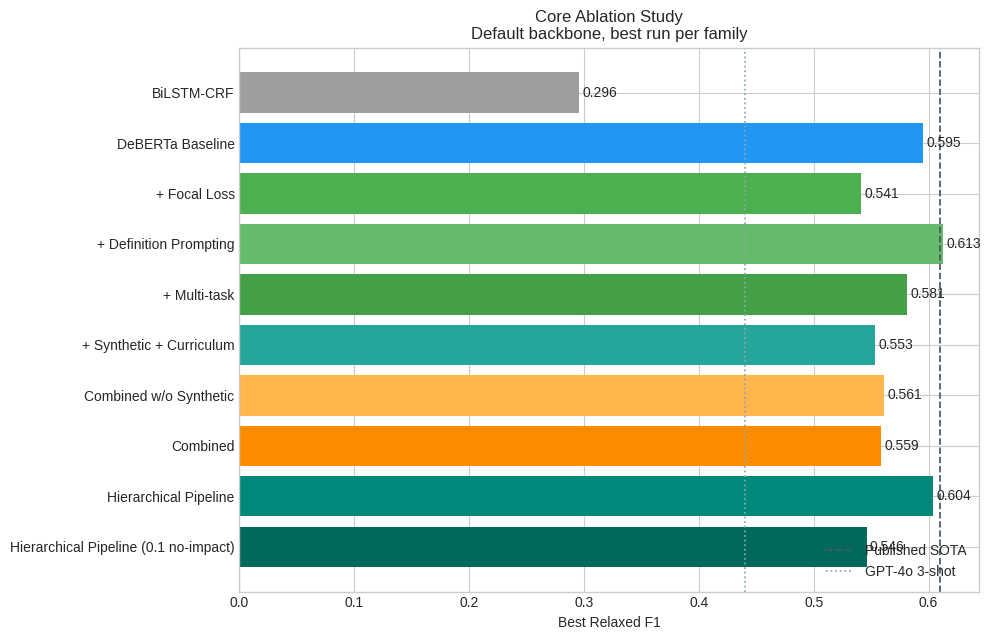


Default-backbone core ablation selected by strict F1:


,display_name,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_dev_loss,artifact_root
0,BiLSTM-CRF,bilstm_crf_lr0p0005,5e-04,0.285,0.273585,2.981249,outputs_new_final_clean
1,DeBERTa Baseline,deberta_baseline_lr5em05,5e-05,0.545,0.421456,0.259762,outputs_new_final_v5
2,+ Focal Loss,deberta_focal_lr5em05,5e-05,0.538,0.358108,0.085471,outputs_new_final_v5
3,+ Definition Prompting,deberta_definition_lr2em05,2e-05,0.561,0.440816,0.238945,outputs_new_final_clean
4,+ Multi-task,deberta_multitask_lr2em05,2e-05,0.550,0.393701,0.279913,outputs_new_final_v5
5,+ Synthetic + Curriculum,deberta_synthetic_curriculum_lr5em05,5e-05,0.553,0.413043,0.263531,outputs_new_final_clean
6,Combined w/o Synthetic,deberta_combined_no_synth_lr5em05,5e-05,0.557,0.366197,0.107200,outputs_new_final_v5
7,Combined,deberta_combined_lr2em05,2e-05,0.558,0.374194,0.094828,outputs_new_final_v2
8,Hierarchical Pipeline,hierarchical_deberta_lr5em05,5e-05,0.481,0.386266,NaN,outputs_new_final_clean
9,Hierarchical Pipeline (0.1 no-impact),hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,outputs_new_final_v2


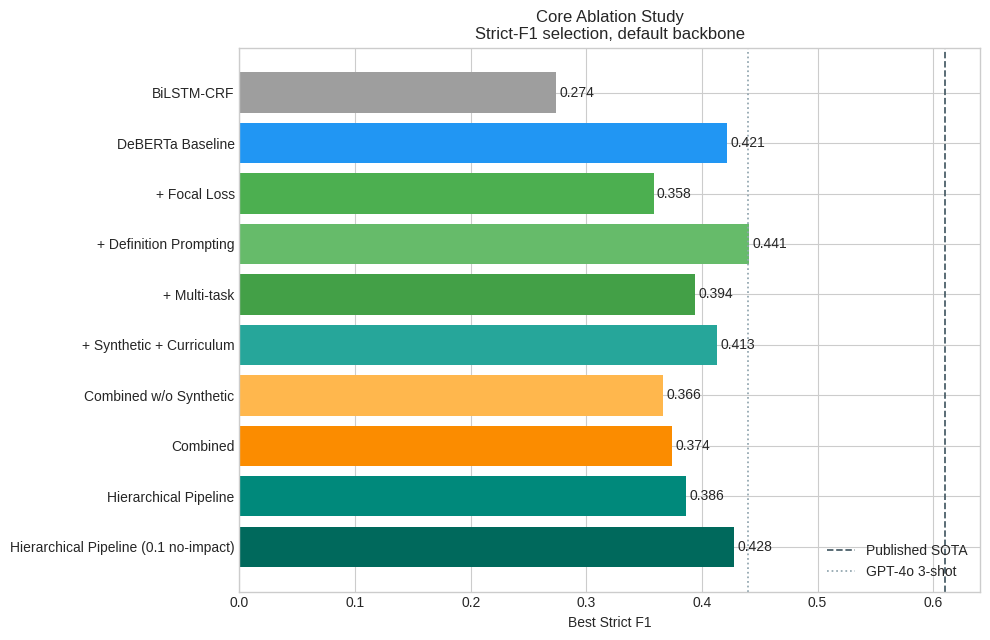

In [27]:
core_rows = pick_rows(best_default_rows, CORE_ABLATION_ORDER)
core_rows_strict = pick_rows(best_default_rows_strict, CORE_ABLATION_ORDER)

print('Default-backbone core ablation selected by relaxed F1:')
display_rows(
    core_rows,
    columns=[
        'display_name',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_dev_loss',
        'artifact_root',
    ],
)
plot_barh(core_rows, 'Core Ablation Study', 'Default backbone, best run per family', metric_key='best_relaxed_f1')

print('\nDefault-backbone core ablation selected by strict F1:')
display_rows(
    core_rows_strict,
    columns=[
        'display_name',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_dev_loss',
        'artifact_root',
    ],
)
plot_barh(core_rows_strict, 'Core Ablation Study', 'Strict-F1 selection, default backbone', metric_key='best_strict_f1')


## Advanced Recipes and Extra Pipelines


Advanced recipes (default backbone):


,display_name,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,artifact_root
0,Recall Boost (seed 42),recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.311864,outputs_new_final_v2
1,Recall Boost (seed 123),recall_boost_ow02_s123_lr2em05,2e-05,0.567,0.354949,outputs_new_final_clean
2,R-Drop (seed 42),rdrop_a1_s42_lr2em05,2e-05,0.577,0.337662,outputs_new_final_v2
3,R-Drop (seed 123),rdrop_a1_s123_lr2em05,2e-05,0.577,0.380000,outputs_new_final_v5
4,FGM + SWA (seed 42),fgm05_swa_s42_lr2em05,2e-05,0.579,0.348123,outputs_new_final_clean


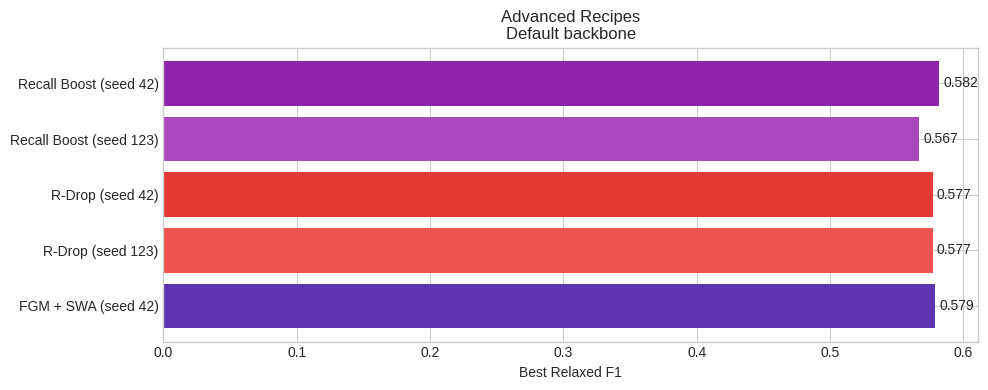


Extra pipelines (default backbone):


,display_name,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,artifact_root
0,Hierarchical Pipeline,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,outputs_new_final_v2
1,Hierarchical Pipeline (0.1 no-impact),hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,outputs_new_final_v2
2,Two-Step Pipeline,two_step_impact_pipeline_lr2em05,2e-05,0.534,0.404494,outputs_new_final_v5
3,Sentence + Token Hierarchy,sentence_token_hierarchy_lr5em05,5e-05,0.530,0.374502,outputs_new_final_v5


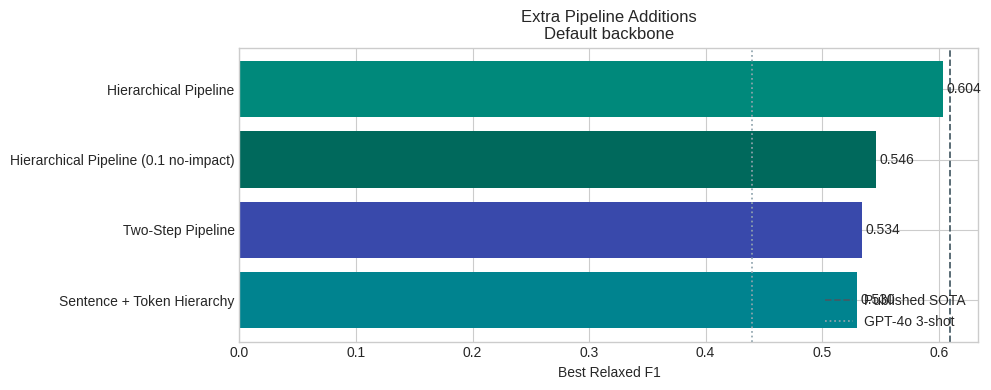

In [28]:
advanced_rows = pick_rows(best_default_rows, ADVANCED_ORDER)
extra_rows = pick_rows(best_default_rows, EXTRA_PIPELINE_ORDER)

print('Advanced recipes (default backbone):')
display_rows(
    advanced_rows,
    columns=['display_name', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_strict_f1', 'artifact_root'],
)
if advanced_rows:
    plot_barh(advanced_rows, 'Advanced Recipes', 'Default backbone', metric_key='best_relaxed_f1', add_reference_lines=False)

print('\nExtra pipelines (default backbone):')
display_rows(
    extra_rows,
    columns=['display_name', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_strict_f1', 'artifact_root'],
)
if extra_rows:
    plot_barh(extra_rows, 'Extra Pipeline Additions', 'Default backbone', metric_key='best_relaxed_f1', add_reference_lines=True)


## Backbone Comparisons


In [29]:
backbone_rows = [row for row in run_rows if row.get('backbone') != 'default']

if backbone_rows:
    print('Top backbone runs sorted by relaxed F1:')
    display_rows(
        sort_rows_by_metric(backbone_rows, 'best_relaxed_f1'),
        columns=[
            'artifact_root',
            'artifact_scope',
            'base_family',
            'backbone',
            'experiment_name',
            'lr_display',
            'best_relaxed_f1',
            'best_strict_f1',
            'topk_saved',
        ],
        max_rows=40,
    )

    selected_base_families = [
        'deberta_baseline',
        'deberta_definition',
        'deberta_multitask',
        'deberta_combined',
        'hierarchical_deberta',
        'two_step_impact_pipeline',
        'sentence_token_hierarchy',
    ]
    backbone_best_rows = []
    for row in best_rows:
        if row.get('backbone') == 'default':
            continue
        if row.get('base_family') in selected_base_families:
            backbone_best_rows.append(row)

    print('\nBest rows per backbone family:')
    display_rows(
        sort_rows_by_metric(backbone_best_rows, 'best_relaxed_f1'),
        columns=['base_family', 'backbone', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_strict_f1', 'artifact_root'],
    )
else:
    print('No Reddit / mental-health backbone artifacts found yet.')


Top backbone runs sorted by relaxed F1:


,artifact_root,artifact_scope,base_family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,topk_saved
0,outputs_new_final_v5,stress_roberta,recall_boost_ow02_s123,stress_roberta,recall_boost_ow02_s123_stress_roberta_lr2em05,2e-05,0.533,0.250000,5.0
1,outputs_new_final_v5,stress_roberta,deberta_focal,stress_roberta,deberta_focal_stress_roberta_lr2em05,2e-05,0.519,0.268657,5.0
2,outputs_new_final_v5,stress_roberta,deberta_combined,stress_roberta,deberta_combined_stress_roberta_lr5em05,5e-05,0.517,0.288462,5.0
3,outputs_new_final_v5,stress_roberta,recall_boost_ow02_s42,stress_roberta,recall_boost_ow02_s42_stress_roberta_lr2em05,2e-05,0.513,0.238806,5.0
4,outputs_new_final_v5,stress_roberta,deberta_combined_no_synth,stress_roberta,deberta_combined_no_synth_stress_roberta_lr2em05,2e-05,0.510,0.240000,5.0
5,outputs_new_final_v5,stress_roberta,deberta_focal,stress_roberta,deberta_focal_stress_roberta_lr5em05,5e-05,0.510,0.259259,5.0
6,outputs_new_final_v5,stress_roberta,recall_boost_ow02_s123,stress_roberta,recall_boost_ow02_s123_stress_roberta_lr5em05,5e-05,0.508,0.313869,5.0
7,outputs_new_final_v5,stress_roberta,rdrop_a1_s123,stress_roberta,rdrop_a1_s123_stress_roberta_lr5em05,5e-05,0.489,0.246988,5.0
8,outputs_new_final_v5,stress_roberta,rdrop_a1_s42,stress_roberta,rdrop_a1_s42_stress_roberta_lr5em05,5e-05,0.486,0.234940,5.0
9,outputs_new_final_v5,stress_roberta,deberta_baseline,stress_roberta,deberta_baseline_stress_roberta_lr2em05,2e-05,0.482,0.270463,5.0



Best rows per backbone family:


,base_family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,artifact_root
0,deberta_combined,stress_roberta,deberta_combined_stress_roberta_lr5em05,5e-05,0.517,0.288462,outputs_new_final_v5
1,deberta_baseline,stress_roberta,deberta_baseline_stress_roberta_lr2em05,2e-05,0.482,0.270463,outputs_new_final_v5
2,deberta_definition,stress_roberta,deberta_definition_stress_roberta_lr5em05,5e-05,0.480,0.307692,outputs_new_final_v5
3,deberta_multitask,stress_roberta,deberta_multitask_stress_roberta_lr5em05,5e-05,0.456,0.282759,outputs_new_final_v5
4,hierarchical_deberta,stress_roberta,hierarchical_deberta_stress_roberta_lr5em05,5e-05,0.443,0.343612,outputs_new_final_v5
5,deberta_baseline,socbert,deberta_baseline_socbert_lr5em05,5e-05,0.404,0.277372,outputs_new_final_v5
6,deberta_combined,socbert,deberta_combined_socbert_lr2em05,2e-05,0.404,0.181818,outputs_new_final_v5
7,two_step_impact_pipeline,stress_roberta,two_step_impact_pipeline_stress_roberta_lr2em05,2e-05,0.403,0.303502,outputs_new_final_v5
8,sentence_token_hierarchy,stress_roberta,sentence_token_hierarchy_stress_roberta_lr2em05,2e-05,0.397,0.259542,outputs_new_final_v5
9,sentence_token_hierarchy,socbert,sentence_token_hierarchy_socbert_lr5em05,5e-05,0.388,0.306513,outputs_new_final_v5


## Ablation Matrix Runs


In [30]:
matrix_rows = [row for row in run_rows if row.get('family_group') == 'ablation_matrix']

if matrix_rows:
    print('Top ablation-matrix runs sorted by relaxed F1:')
    display_rows(
        sort_rows_by_metric(matrix_rows, 'best_relaxed_f1'),
        columns=['family', 'backbone', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_strict_f1', 'artifact_root'],
        max_rows=30,
    )

    print('\nTop ablation-matrix runs sorted by strict F1:')
    display_rows(
        sort_rows_by_metric(matrix_rows, 'best_strict_f1'),
        columns=['family', 'backbone', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_strict_f1', 'artifact_root'],
        max_rows=30,
    )
else:
    print('No ablation-matrix result files found yet.')


Top ablation-matrix runs sorted by relaxed F1:


,family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,artifact_root
0,matrix_focal_definition_multitask,default,matrix_focal_definition_multitask_lr2em05,2e-05,0.575,0.350318,outputs_new_final_v5
1,matrix_focal_definition_multitask_synthcurr,default,matrix_focal_definition_multitask_synthcurr_lr...,5e-05,0.571,0.356643,outputs_new_final_v5
2,matrix_definition_synthcurr,default,matrix_definition_synthcurr_lr2em05,2e-05,0.569,0.383275,outputs_new_final_v5
3,matrix_synthcurr,default,matrix_synthcurr_lr2em05,2e-05,0.566,0.368056,outputs_new_final_v5
4,matrix_focal_multitask,default,matrix_focal_multitask_lr2em05,2e-05,0.562,0.346290,outputs_new_final_v5
5,matrix_focal_definition_multitask_synthcurr,default,matrix_focal_definition_multitask_synthcurr_lr...,2e-05,0.560,0.355705,outputs_new_final_v5
6,matrix_focal_definition,default,matrix_focal_definition_lr5em05,5e-05,0.558,0.339506,outputs_new_final_v5
7,matrix_multitask,default,matrix_multitask_lr5em05,5e-05,0.558,0.386861,outputs_new_final_v5
8,matrix_multitask,default,matrix_multitask_lr2em05,2e-05,0.557,0.349206,outputs_new_final_v5
9,matrix_multitask_synthcurr,default,matrix_multitask_synthcurr_lr5em05,5e-05,0.550,0.318339,outputs_new_final_v5



Top ablation-matrix runs sorted by strict F1:


,family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,artifact_root
0,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr1em05,1e-05,0.443,0.491228,outputs_new_final_v5
1,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr2em05,2e-05,0.493,0.484581,outputs_new_final_v5
2,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr5em06,5e-06,0.438,0.456140,outputs_new_final_v5
3,matrix_focal_definition_synthcurr,default,matrix_focal_definition_synthcurr_lr5em05,5e-05,0.539,0.403042,outputs_new_final_v5
4,matrix_base,default,matrix_base_lr5em05,5e-05,0.501,0.396694,outputs_new_final_v5
5,matrix_definition,default,matrix_definition_lr5em05,5e-05,0.546,0.393162,outputs_new_final_v5
6,matrix_two_step,default,matrix_two_step_lr2em05,2e-05,0.491,0.391304,outputs_new_final_v5
7,matrix_multitask,default,matrix_multitask_lr5em05,5e-05,0.558,0.386861,outputs_new_final_v5
8,matrix_definition_synthcurr,default,matrix_definition_synthcurr_lr2em05,2e-05,0.569,0.383275,outputs_new_final_v5
9,matrix_synthcurr,default,matrix_synthcurr_lr5em05,5e-05,0.535,0.383142,outputs_new_final_v5


## Learning Curves

The plots below track the best selected runs across four complementary signals whenever they are available in the training logs:

- `relaxed_f1`: whether the model is improving under the task's overlap-tolerant metric
- `strict_f1`: whether exact span and label matching is also improving
- `dev_loss`: whether validation optimization is still getting better
- `train_loss`: whether the model is still learning smoothly or starting to overfit

Looking at these together helps separate genuine task improvements from optimization-only improvements.


### Plotted Runs
- `deberta_definition_lr5em05` from `outputs_new_final_v5` for **DeBERTa + Definition Prompting**
- `hierarchical_deberta_lr2em05` from `outputs_new_final_v2` for **Hierarchical Pipeline**
- `deberta_baseline_lr2em05` from `outputs_new_final_v2` for **DeBERTa Baseline**
- `deberta_multitask_lr5em05` from `outputs_new_final_v2` for **DeBERTa + Multi-task**
- `deberta_combined_lr2em05` from `outputs_new_final_v5` for **Combined**
- `two_step_impact_pipeline_lr2em05` from `outputs_new_final_v5` for **Two-Step Pipeline**
- `sentence_token_hierarchy_lr5em05` from `outputs_new_final_v5` for **Sentence + Token Hierarchy**

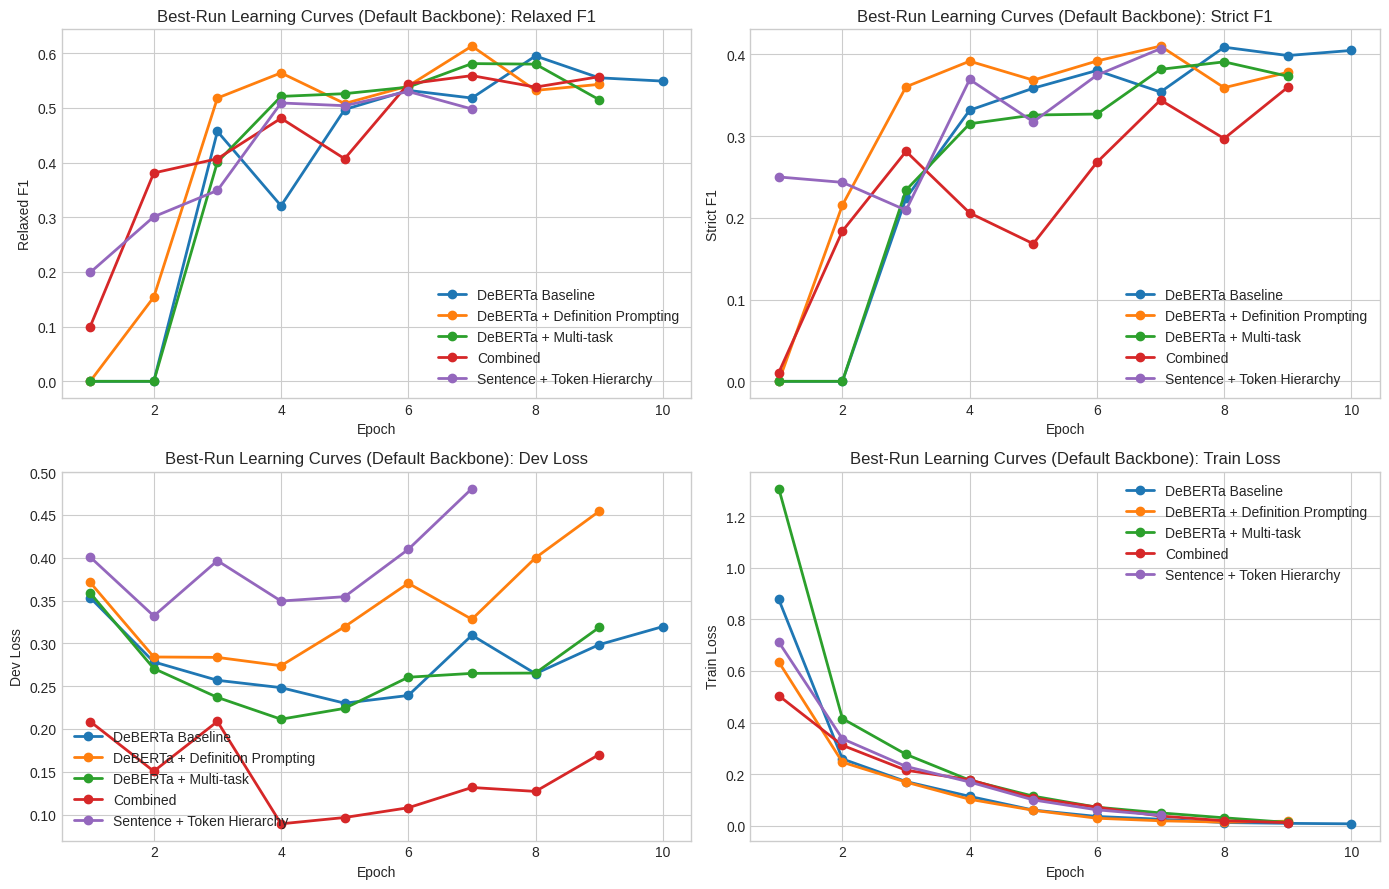

In [31]:
learning_curve_families = [
    'deberta_baseline',
    'deberta_definition',
    'deberta_multitask',
    'deberta_combined',
    'hierarchical_deberta',
    'two_step_impact_pipeline',
    'sentence_token_hierarchy',
]

display_markdown(
    '### Plotted Runs\n' + '\n'.join(
        f'- `{row['experiment_name']}` from `{row['artifact_root']}` for **{row['family_display_name']}**'
        for row in sort_rows_by_metric([
            candidate for candidate in best_rows
            if candidate.get('backbone') == 'default' and candidate.get('base_family') in learning_curve_families
        ], 'best_relaxed_f1')
    )
)

plot_learning_curves(
    best_rows,
    logs_by_run_key,
    families=learning_curve_families,
    backbone='default',
    metrics=['relaxed_f1', 'strict_f1', 'dev_loss', 'train_loss'],
    title='Best-Run Learning Curves (Default Backbone)',
)


## Checkpoint Inventory and Candidate Selection


In [32]:
print('Top candidate families sorted by relaxed F1:')
candidate_rows = sort_rows_by_metric(best_rows, 'best_relaxed_f1')
display_rows(
    candidate_rows,
    columns=[
        'artifact_root',
        'family',
        'backbone',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'topk_saved',
        'top_checkpoint_path',
    ],
    max_rows=20,
)

print('\nTop candidate families sorted by strict F1:')
candidate_rows_strict = sort_rows_by_metric(best_rows_strict, 'best_strict_f1')
display_rows(
    candidate_rows_strict,
    columns=[
        'artifact_root',
        'family',
        'backbone',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'topk_saved',
        'top_checkpoint_path',
    ],
    max_rows=20,
)

best_sources = [row['experiment_name'] for row in candidate_rows[:8]]
print('\nSuggested sources for model soup / ensemble search:')
for source in best_sources:
    print(f'  --source-experiment {source}')


Top candidate families sorted by relaxed F1:


,artifact_root,family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,topk_saved,top_checkpoint_path
0,outputs_new_final_v5,deberta_definition,default,deberta_definition_lr5em05,5e-05,0.613,0.410072,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,outputs_new_final_v2,hierarchical_deberta,default,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN
2,outputs_new_final_v2,deberta_baseline,default,deberta_baseline_lr2em05,2e-05,0.595,0.408759,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,outputs_new_final_v2,recall_boost_ow02_s42,default,recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.311864,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
4,outputs_new_final_v2,deberta_multitask,default,deberta_multitask_lr5em05,5e-05,0.581,0.381625,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
5,outputs_new_final_clean,fgm05_swa_s42,default,fgm05_swa_s42_lr2em05,2e-05,0.579,0.348123,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
6,outputs_new_final_v2,rdrop_a1_s42,default,rdrop_a1_s42_lr2em05,2e-05,0.577,0.337662,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
7,outputs_new_final_v5,rdrop_a1_s123,default,rdrop_a1_s123_lr2em05,2e-05,0.577,0.380000,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
8,outputs_new_final_v5,matrix_focal_definition_multitask,default,matrix_focal_definition_multitask_lr2em05,2e-05,0.575,0.350318,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
9,outputs_new_final_v5,matrix_focal_definition_multitask_synthcurr,default,matrix_focal_definition_multitask_synthcurr_lr...,5e-05,0.571,0.356643,5.0,/home/ismail/Documents/NLP_assignment/outputs_...



Top candidate families sorted by strict F1:


,artifact_root,family,backbone,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,topk_saved,top_checkpoint_path
0,outputs_new_final_v5,gliner_finetune,default,gliner_finetune_lr2em05,2e-05,0.524,0.510638,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,outputs_new_final_v5,matrix_span_nested_gliner,default,matrix_span_nested_gliner_lr1em05,1e-05,0.443,0.491228,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
2,outputs_new_final_clean,deberta_definition,default,deberta_definition_lr2em05,2e-05,0.561,0.440816,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,outputs_new_final_v2,hierarchical_deberta_0.1_no_impact,default,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN
4,outputs_new_final_v5,deberta_baseline,default,deberta_baseline_lr5em05,5e-05,0.545,0.421456,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
5,outputs_new_final_clean,deberta_synthetic_curriculum,default,deberta_synthetic_curriculum_lr5em05,5e-05,0.553,0.413043,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
6,outputs_new_final_v5,two_step_impact_pipeline,default,two_step_impact_pipeline_lr2em05,2e-05,0.534,0.404494,NaN,NaN
7,outputs_new_final_v5,matrix_focal_definition_synthcurr,default,matrix_focal_definition_synthcurr_lr5em05,5e-05,0.539,0.403042,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
8,outputs_new_final_v5,sentence_token_hierarchy,default,sentence_token_hierarchy_lr2em05,2e-05,0.409,0.400000,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
9,outputs_new_final_clean,recall_boost_ow02_s42,default,recall_boost_ow02_s42_lr5em05,5e-05,0.558,0.398601,5.0,/home/ismail/Documents/NLP_assignment/outputs_...



Suggested sources for model soup / ensemble search:
  --source-experiment deberta_definition_lr5em05
  --source-experiment hierarchical_deberta_lr2em05
  --source-experiment deberta_baseline_lr2em05
  --source-experiment recall_boost_ow02_s42_lr2em05
  --source-experiment deberta_multitask_lr5em05
  --source-experiment fgm05_swa_s42_lr2em05
  --source-experiment rdrop_a1_s42_lr2em05
  --source-experiment rdrop_a1_s123_lr2em05


## Ensemble Search Results


Ensemble search artifacts sorted by relaxed F1:


,artifact_root,artifact_scope,experiment_name,vote_method,candidate_count,total_combinations,best_overall_by_relaxed_f1,best_overall_by_strict_f1,best_overall_by_relaxed_models
0,outputs_cross_version_ensembles,.,ensemble_search_v2_v5_top7_relaxed_strict,majority_vote,28,122409,0.635,0.517857,outputs_new_final_v2::hierarchical_deberta_lr2...
1,outputs_new_final_v2,.,ensemble_search_2to5_with_hier,majority_vote,5,26,0.631,0.405498,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
2,outputs_new_final_v2,.,dev_eval_best_ensemble,majority_vote,4,1,0.625,0.380623,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
3,outputs_new_final_v2,.,ensemble_search_2to5,probability_average,7,112,0.614,0.431095,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
4,outputs_new_final_clean,.,ensemble_search_best9_majority,majority_vote,9,372,0.609,0.444444,"fgm05_swa_s42_lr2em05, recall_boost_ow02_s123_..."
5,outputs_new_final_clean,.,ensemble_search_best8,probability_average,8,210,0.602,0.453532,"fgm05_swa_s42_lr2em05, rdrop_a1_s123_lr2em05, ..."
6,outputs_new_final_clean,.,ensemble_search_2to5,probability_average,6,56,0.601,0.437736,"recall_boost_ow02_s42_lr2em05, rdrop_a1_s123_l..."



Ensemble search artifacts sorted by strict F1:


,artifact_root,artifact_scope,experiment_name,vote_method,candidate_count,total_combinations,best_overall_by_relaxed_f1,best_overall_by_strict_f1,best_overall_by_strict_models
0,outputs_cross_version_ensembles,.,ensemble_search_v2_v5_top7_relaxed_strict,majority_vote,28,122409,0.635,0.517857,outputs_new_final_v2::hierarchical_deberta_lr2...
1,outputs_new_final_clean,.,ensemble_search_best8,probability_average,8,210,0.602,0.453532,"fgm05_swa_s42_lr2em05, recall_boost_ow02_s42_l..."
2,outputs_new_final_clean,.,ensemble_search_best9_majority,majority_vote,9,372,0.609,0.444444,"rdrop_a1_s123_lr2em05, deberta_definition_lr5e..."
3,outputs_new_final_clean,.,ensemble_search_2to5,probability_average,6,56,0.601,0.437736,"deberta_definition_lr5em05, fgm05_swa_s42_lr2em05"
4,outputs_new_final_v2,.,ensemble_search_2to5,probability_average,7,112,0.614,0.431095,"deberta_baseline_lr2em05, rdrop_a1_s42_lr2em05"
5,outputs_new_final_v2,.,ensemble_search_2to5_with_hier,majority_vote,5,26,0.631,0.405498,"deberta_baseline_lr2em05, fgm05_swa_s42_lr2em0..."
6,outputs_new_final_v2,.,dev_eval_best_ensemble,majority_vote,4,1,0.625,0.380623,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."


,display_name,best_relaxed_f1,best_strict_f1,relaxed_precision,relaxed_recall,models,strict_models
0,2 models,0.623,0.465306,0.586,0.664,outputs_new_final_v2::hierarchical_deberta_lr2...,"outputs_new_final_v2::gliner_finetune_lr2em05,..."
1,3 models,0.621,0.506912,0.638,0.605,outputs_new_final_v2::hierarchical_deberta_lr2...,"outputs_new_final_v2::gliner_finetune_lr2em05,..."
2,4 models,0.635,0.508621,0.648,0.623,outputs_new_final_v2::hierarchical_deberta_lr2...,outputs_new_final_v2::deberta_baseline_lr2em05...
3,5 models,0.631,0.517857,0.670,0.597,outputs_new_final_v2::hierarchical_deberta_lr2...,outputs_new_final_v2::hierarchical_deberta_lr2...


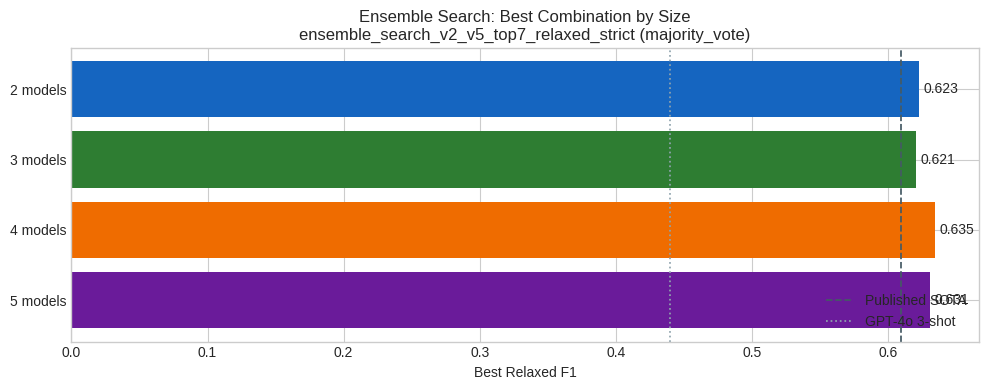


Top 2 combinations for each size and vote type, sorted by relaxed F1:


,artifact_root,vote_method,num_models,rank_within_group,best_relaxed_f1,best_strict_f1,ensemble_experiment_name,models
0,outputs_cross_version_ensembles,majority_vote,4,1,0.635,0.395833,ensemble_search_v2_v5_top7_relaxed_strict,outputs_new_final_v2::hierarchical_deberta_lr2...
1,outputs_cross_version_ensembles,majority_vote,4,2,0.634,0.391459,ensemble_search_v2_v5_top7_relaxed_strict,outputs_new_final_v2::hierarchical_deberta_lr2...
2,outputs_cross_version_ensembles,majority_vote,5,1,0.631,0.397163,ensemble_search_v2_v5_top7_relaxed_strict,outputs_new_final_v2::hierarchical_deberta_lr2...
3,outputs_cross_version_ensembles,majority_vote,5,2,0.631,0.402985,ensemble_search_v2_v5_top7_relaxed_strict,outputs_new_final_v2::hierarchical_deberta_lr2...
4,outputs_new_final_v2,majority_vote,4,1,0.631,0.387543,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
5,outputs_new_final_v2,majority_vote,3,1,0.625,0.383275,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
6,outputs_new_final_v2,majority_vote,4,2,0.625,0.380623,dev_eval_best_ensemble,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
7,outputs_new_final_v2,majority_vote,2,1,0.624,0.385135,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, hierarchical_deberta..."
8,outputs_cross_version_ensembles,majority_vote,2,1,0.623,0.382253,ensemble_search_v2_v5_top7_relaxed_strict,outputs_new_final_v2::hierarchical_deberta_lr2...
9,outputs_cross_version_ensembles,majority_vote,3,1,0.621,0.383275,ensemble_search_v2_v5_top7_relaxed_strict,outputs_new_final_v2::hierarchical_deberta_lr2...



Top 2 combinations for each size and vote type, sorted by strict F1:


,artifact_root,vote_method,num_models,rank_within_group,best_relaxed_f1,best_strict_f1,ensemble_experiment_name,models
0,outputs_new_final_clean,majority_vote,4,2,0.609,0.444444,ensemble_search_best9_majority,"rdrop_a1_s123_lr2em05, deberta_definition_lr5e..."
1,outputs_new_final_v2,probability_average,2,2,0.606,0.431095,ensemble_search_2to5,"deberta_baseline_lr2em05, rdrop_a1_s42_lr2em05"
2,outputs_new_final_clean,majority_vote,5,2,0.605,0.430556,ensemble_search_best9_majority,"fgm05_swa_s42_lr2em05, rdrop_a1_s123_lr2em05, ..."
3,outputs_cross_version_ensembles,majority_vote,3,2,0.620,0.423792,ensemble_search_v2_v5_top7_relaxed_strict,outputs_new_final_v2::deberta_baseline_lr2em05...
4,outputs_new_final_clean,probability_average,5,2,0.602,0.423358,ensemble_search_best8,"fgm05_swa_s42_lr2em05, rdrop_a1_s123_lr2em05, ..."
5,outputs_new_final_clean,probability_average,5,1,0.602,0.422535,ensemble_search_best8,"fgm05_swa_s42_lr2em05, rdrop_a1_s123_lr2em05, ..."
6,outputs_new_final_clean,probability_average,4,1,0.600,0.421053,ensemble_search_best8,"rdrop_a1_s123_lr2em05, recall_boost_ow02_s42_l..."
7,outputs_new_final_clean,probability_average,4,2,0.600,0.421053,ensemble_search_best8,"recall_boost_ow02_s42_lr2em05, recall_boost_ow..."
8,outputs_new_final_v2,probability_average,5,1,0.610,0.415771,ensemble_search_2to5,"deberta_baseline_lr2em05, deberta_multitask_lr..."
9,outputs_new_final_clean,probability_average,3,1,0.601,0.415493,ensemble_search_2to5,"recall_boost_ow02_s42_lr2em05, rdrop_a1_s123_l..."


In [33]:
if ensemble_rows:
    print('Ensemble search artifacts sorted by relaxed F1:')
    display_rows(
        sort_rows_by_metric(ensemble_rows, 'best_overall_by_relaxed_f1'),
        columns=[
            'artifact_root',
            'artifact_scope',
            'experiment_name',
            'vote_method',
            'candidate_count',
            'total_combinations',
            'best_overall_by_relaxed_f1',
            'best_overall_by_strict_f1',
            'best_overall_by_relaxed_models',
        ],
    )

    print('\nEnsemble search artifacts sorted by strict F1:')
    display_rows(
        sort_rows_by_metric(ensemble_rows, 'best_overall_by_strict_f1'),
        columns=[
            'artifact_root',
            'artifact_scope',
            'experiment_name',
            'vote_method',
            'candidate_count',
            'total_combinations',
            'best_overall_by_relaxed_f1',
            'best_overall_by_strict_f1',
            'best_overall_by_strict_models',
        ],
    )

    best_ensemble_run = sort_rows_by_metric(ensemble_rows, 'best_overall_by_relaxed_f1')[0]
    selected_ensemble_rows = [
        row for row in ensemble_best_by_size_rows
        if row['ensemble_experiment_name'] == best_ensemble_run['experiment_name']
        and row['artifact_root'] == best_ensemble_run['artifact_root']
        and row['artifact_scope'] == best_ensemble_run['artifact_scope']
    ]
    display_rows(
        selected_ensemble_rows,
        columns=['display_name', 'best_relaxed_f1', 'best_strict_f1', 'relaxed_precision', 'relaxed_recall', 'models', 'strict_models'],
    )
    plot_barh(
        selected_ensemble_rows,
        'Ensemble Search: Best Combination by Size',
        f"{best_ensemble_run['experiment_name']} ({best_ensemble_run['vote_method']})",
        metric_key='best_relaxed_f1',
    )

    print('\nTop 2 combinations for each size and vote type, sorted by relaxed F1:')
    display_rows(
        ensemble_top_two_rows,
        columns=[
            'artifact_root',
            'vote_method',
            'num_models',
            'rank_within_group',
            'best_relaxed_f1',
            'best_strict_f1',
            'ensemble_experiment_name',
            'models',
        ],
        sort_by='best_relaxed_f1',
    )

    print('\nTop 2 combinations for each size and vote type, sorted by strict F1:')
    display_rows(
        ensemble_top_two_rows,
        columns=[
            'artifact_root',
            'vote_method',
            'num_models',
            'rank_within_group',
            'best_relaxed_f1',
            'best_strict_f1',
            'ensemble_experiment_name',
            'models',
        ],
        sort_by='best_strict_f1',
    )
else:
    print('No ensemble search artifacts found.')


## Model Soup Results


Best soup per model type selected by relaxed F1:


,artifact_root,model_type,experiment_name,best_relaxed_f1,best_strict_f1,num_checkpoints,source_experiments
0,outputs_new_final_v2,deberta_multitask,recall_boost_ow02_s42_lr2em05_soup,0.595,0.331126,3,recall_boost_ow02_s42_lr2em05
1,outputs_new_final_v2,deberta,deberta_baseline_lr2em05_soup,0.589,0.436090,3,deberta_baseline_lr2em05
2,outputs_new_final_clean,bilstm_crf,bilstm_crf_lr0p0005_soup,0.296,0.273171,5,bilstm_crf_lr0p0005



Did model soup improve over the best source model?


,artifact_root,model_type,experiment_name,best_relaxed_f1,best_source_relaxed_experiment,best_source_relaxed_f1,delta_relaxed_vs_best_source,best_strict_f1,best_source_strict_experiment,best_source_strict_f1,delta_strict_vs_best_source
0,outputs_new_final_v5,deberta,matrix_focal_definition_lr0p0005_top3_soup,0.440,matrix_focal_definition_lr0p0005,0.230,0.210,0.229268,matrix_focal_definition_lr0p0005,0.052388,0.176880
1,outputs_new_final_clean,deberta_multitask,rdrop_a1_s123_lr0p0005_soup,0.541,rdrop_a1_s123_lr0p0005,0.442,0.099,0.330159,rdrop_a1_s123_lr0p0005,0.332075,-0.001917
2,outputs_new_final_v5,deberta_multitask,deberta_combined_no_synth_lr5em05_top3_soup,0.539,deberta_combined_no_synth_lr5em05,0.462,0.077,0.352941,deberta_combined_no_synth_lr5em05,0.249351,0.103591
3,outputs_new_final_v2,deberta_multitask,deberta_multitask_lr5em05_soup,0.574,deberta_multitask_lr5em05,0.497,0.077,0.387543,deberta_multitask_lr5em05,0.323741,0.063802
4,outputs_new_final_v5,deberta_multitask,deberta_combined_no_synth_lr5em05_top5_soup,0.538,deberta_combined_no_synth_lr5em05,0.462,0.076,0.343949,deberta_combined_no_synth_lr5em05,0.249351,0.094598
5,outputs_new_final_v2,deberta,deberta_baseline_lr2em05_soup,0.589,deberta_baseline_lr2em05,0.516,0.073,0.436090,deberta_baseline_lr2em05,0.370909,0.065181
6,outputs_new_final_v5,deberta_multitask,deberta_multitask_lr5em05_top5_soup,0.562,deberta_multitask_lr5em05,0.497,0.065,0.404762,deberta_multitask_lr5em05,0.323741,0.081021
7,outputs_new_final_v5,deberta,deberta_focal_lr5em05_top3_soup,0.549,deberta_focal_lr5em05,0.484,0.065,0.324841,deberta_focal_lr5em05,0.298246,0.026595
8,outputs_new_final_clean,deberta_multitask,fgm05_swa_s42_lr5em05_soup,0.583,fgm05_swa_s42_lr5em05,0.524,0.059,0.383838,fgm05_swa_s42_lr5em05,0.333333,0.050505
9,outputs_new_final_v5,deberta,deberta_definition_lr5em05_top3_soup,0.545,deberta_definition_lr5em05,0.488,0.057,0.400000,deberta_definition_lr5em05,0.422535,-0.022535


### Soup Gain Summary
- Soups with a positive relaxed-F1 gain over their best source model: **65 / 178**
- Soups with a positive strict-F1 gain over their best source model: **60 / 178**
- Positive deltas mean the soup outperformed the best individual source run used to build it.


Top ranked model soups by strict F1:


,artifact_root,model_type,experiment_name,best_relaxed_f1,best_strict_f1,num_checkpoints,num_source_experiments,source_experiments
0,outputs_new_final_v5,deberta,deberta_synthetic_curriculum_lr5em05_top5_soup,0.529,0.442623,5,1,deberta_synthetic_curriculum_lr5em05
1,outputs_new_final_v5,deberta,deberta_baseline_lr5em05_top5_soup,0.557,0.436214,5,1,deberta_baseline_lr5em05
2,outputs_new_final_v2,deberta,deberta_baseline_lr2em05_soup,0.589,0.436090,3,1,deberta_baseline_lr2em05
3,outputs_new_final_v5,deberta,deberta_baseline_lr5em05_top3_soup,0.556,0.414634,3,1,deberta_baseline_lr5em05
4,outputs_new_final_v5,deberta,deberta_synthetic_curriculum_lr5em05_top3_soup,0.545,0.410646,3,1,deberta_synthetic_curriculum_lr5em05
5,outputs_new_final_v5,deberta,matrix_base_lr5em05_top3_soup,0.504,0.406639,3,1,matrix_base_lr5em05
6,outputs_new_final_v5,deberta,matrix_base_lr5em05_top5_soup,0.500,0.404858,5,1,matrix_base_lr5em05
7,outputs_new_final_v5,deberta_multitask,deberta_multitask_lr5em05_top5_soup,0.562,0.404762,5,1,deberta_multitask_lr5em05
8,outputs_new_final_v2,deberta,deberta_synthetic_curriculum_lr5em05_soup,0.548,0.402930,3,1,deberta_synthetic_curriculum_lr5em05
9,outputs_new_final_v2,deberta_multitask,rdrop_a1_s123_lr2em05_soup,0.557,0.401361,3,1,rdrop_a1_s123_lr2em05


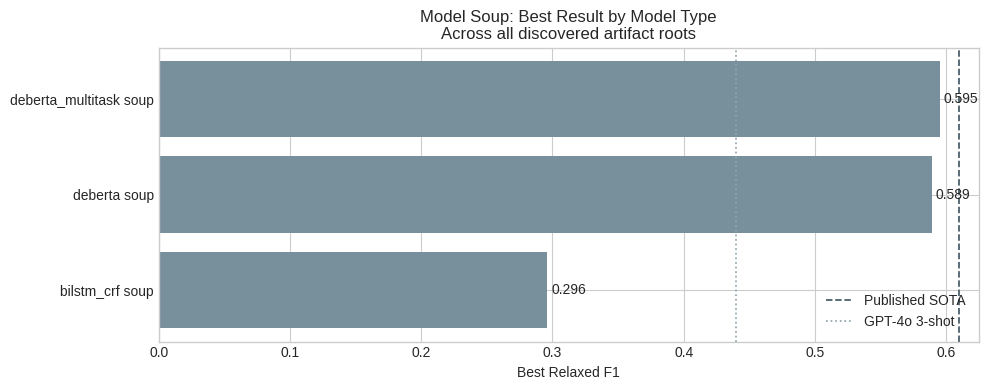

In [34]:
if soup_rows:
    print('Best soup per model type selected by relaxed F1:')
    display_rows(
        best_soup_rows,
        columns=[
            'artifact_root',
            'model_type',
            'experiment_name',
            'best_relaxed_f1',
            'best_strict_f1',
            'num_checkpoints',
            'source_experiments',
        ],
    )

    print('\nDid model soup improve over the best source model?')
    display_rows(
        soup_gain_rows,
        columns=[
            'artifact_root',
            'model_type',
            'experiment_name',
            'best_relaxed_f1',
            'best_source_relaxed_experiment',
            'best_source_relaxed_f1',
            'delta_relaxed_vs_best_source',
            'best_strict_f1',
            'best_source_strict_experiment',
            'best_source_strict_f1',
            'delta_strict_vs_best_source',
        ],
        sort_by='delta_relaxed_vs_best_source',
        max_rows=30,
    )

    improved_relaxed = [row for row in soup_gain_rows if row.get('delta_relaxed_vs_best_source', float('-inf')) > 0]
    improved_strict = [row for row in soup_gain_rows if row.get('delta_strict_vs_best_source', float('-inf')) > 0]
    display_markdown(
        '### Soup Gain Summary\n'
        + f'- Soups with a positive relaxed-F1 gain over their best source model: **{len(improved_relaxed)} / {len(soup_gain_rows)}**\n'
        + f'- Soups with a positive strict-F1 gain over their best source model: **{len(improved_strict)} / {len(soup_gain_rows)}**\n'
        + '- Positive deltas mean the soup outperformed the best individual source run used to build it.'
    )

    print('\nTop ranked model soups by strict F1:')
    display_rows(
        soup_rows,
        columns=[
            'artifact_root',
            'model_type',
            'experiment_name',
            'best_relaxed_f1',
            'best_strict_f1',
            'num_checkpoints',
            'num_source_experiments',
            'source_experiments',
        ],
        sort_by='best_strict_f1',
        max_rows=20,
    )

    soup_plot_rows = []
    for row in best_soup_rows:
        plot_row = dict(row)
        plot_row['display_name'] = f"{row['model_type']} soup"
        plot_row['annotation_label'] = f" ({row['num_checkpoints']} ckpts)"
        soup_plot_rows.append(plot_row)

    plot_barh(
        soup_plot_rows,
        'Model Soup: Best Result by Model Type',
        'Across all discovered artifact roots',
        metric_key='best_relaxed_f1',
    )
else:
    print('No model soup artifacts found.')


## Notes

- Artifact discovery now includes `outputs_cross_version_ensembles`, so cross-version ensemble searches are treated as first-class analysis inputs alongside the main sweeps, soups, and backbone runs.
- The ensemble tables now show explicit relaxed-best and strict-best selections, which matters because the strongest cross-version ensemble may differ depending on which metric you optimize.
- Core ablation and advanced recipe plots stay focused on the default backbone so they remain comparable with the original notebook story.
- Backbone and matrix sections are separate so we do not mix recipe changes with encoder swaps in the same chart.
- All numbers remain dynamically generated from the discovered result files; rerunning the notebook after new experiments finish will refresh the findings automatically.
